# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [1]:
# Começamos importando as principais bibliotecas que vamos utilizar nesse projeto
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

In [2]:
#agora vamos importar o nosso csv
df = pd.read_csv('Mall_Customers.csv')
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [3]:
# Verificando os tipos de dados
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [4]:
# mais uma verificação dos tipos e quantos valores existem em cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Verificando se existem dados nulos ou faltantes
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**Como não existem dados Nulos ou faltantes não há a necessidade de remoção ou qualquer outro tratamento**

In [6]:
# Verificando se existem valores digitados errados
# Mostrando todos os valores unicos que existem nas minhas colunas
valores_unicos = {col: df[col].unique() for col in df.columns}

# Exemplo de apresentação dos resultados:
for coluna, unicos in valores_unicos.items():
    print(f"Coluna: {coluna}")
    print(f"Valores únicos: {unicos}")
    print("="*40)

Coluna: CustomerID
Valores únicos: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200]
Coluna: Gender
Valores únicos: ['Male' 'Female']
Coluna: Age
Valores únicos: [19 21 20 23 31 22 35 64 30 67 58 24 37 52 25 46 54 29 45 40 60 53 18 49
 4

In [7]:
# Verificando a quantidade de valores unicos em cada coluna
print(df.nunique())

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64


**Ao observar os valores únicos não foi constatada a presença de valores com erros na digitação**

In [8]:
# Resolvi renomear apenas as colunas de annual income e spending score para ficar mais fácil de se trabalhar com elas
df = df.rename(columns={'Annual Income (k$)':'Annual Income', 'Spending Score (1-100)': 'Spending Score'})

df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income', 'Spending Score'], dtype='object')

# Agora vamos para a segunda parte do pré-processamento de dados, onde vamos verificar e tratar os possiveis outliers

In [9]:
# Vamos utilizar o describe para saber as métricas como valor min e maximo media e a contagem total de valor
df.describe()

,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


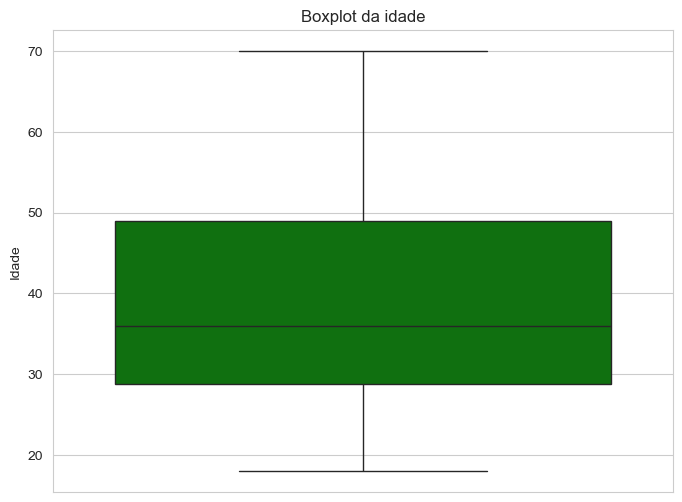

In [10]:
# Feito isso vamos plotar alguns gráfico para conseguir entender melhor a distribuição destes outliers
#Boxplot da idade
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Age', color='green')
plt.title('Boxplot da idade')
plt.ylabel('Idade')
plt.show()

**Apesar de idades amplamente distribuidas variando de menos de 20 anos até 70 não foram encontrados outliers**

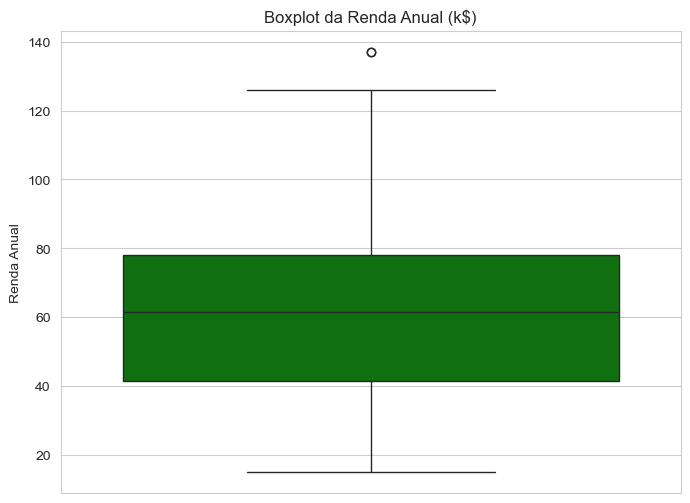

In [11]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Annual Income', color='green')
plt.title('Boxplot da Renda Anual (k$)')
plt.ylabel('Renda Anual')
plt.show()

**Na renda anual foi encontrado somente 1 outlier então vamos a mais análises para saber se vamos remover ou se vamos manter**

In [12]:
df['Annual Income'].describe()

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income, dtype: float64

In [13]:
df_sem_outlier = df[df['Annual Income'] < 130]

df_sem_outlier['Annual Income'].describe()

count    198.000000
mean      59.787879
std       25.237259
min       15.000000
25%       40.500000
50%       61.000000
75%       77.750000
max      126.000000
Name: Annual Income, dtype: float64

**Mesmo com a presença de um outlier as métricas não são drasticamente alteradas em eu optei por manter**

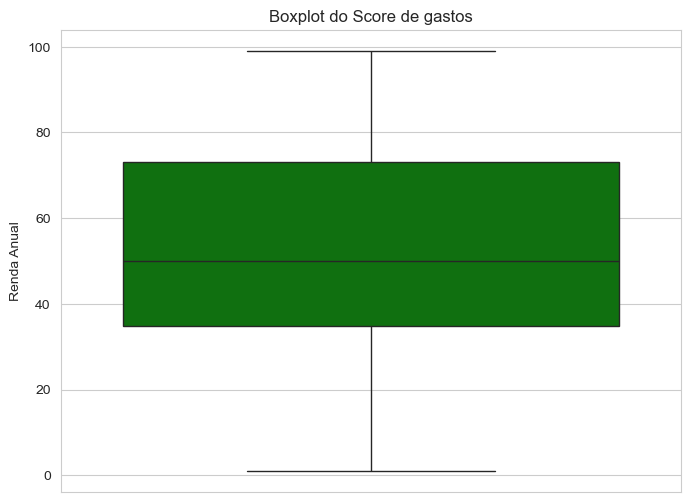

In [14]:
# boxplot do spending score
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Spending Score', color='green')
plt.title('Boxplot do Score de gastos')
plt.ylabel('Renda Anual')
plt.show()

**No Score de gastos também não encontramos nenhum outlier**

## Agora uma análise univariada da minha unica variável categorica

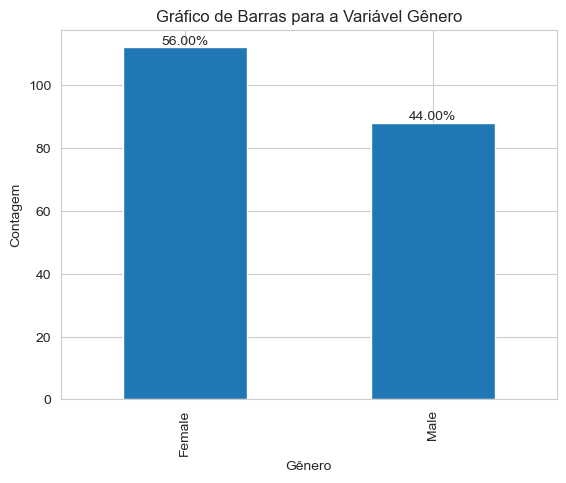

In [15]:
contagem = df['Gender'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')
for i, v in enumerate(contagem):
    label = f'{porcentagem.iloc[i]:.2f}%' 
    ax.text(i, v + 1, label, ha='center')

plt.title('Gráfico de Barras para a Variável Gênero')
plt.xlabel('Gênero')
plt.ylabel('Contagem')

plt.show()

**Aqui podemos ver que a maioria dos clientes são mulheres**

In [16]:
# Antes de iniciar a segunda etapa do pré processamento com análises bivariadas vou encodar a minha variável gênero
# Estou criando um copia do meu df original para não sobrescrever dado nenhum
df_encoded = df.copy()
df_encoded['Gender'] = df_encoded['Gender'].map({'Female': 0, 'Male': 1})

In [17]:
df_encoded.head(10)

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
5,6,0,22,17,76
6,7,0,35,18,6
7,8,0,23,18,94
8,9,1,64,19,3
9,10,0,30,19,72


# Análise Bivariada

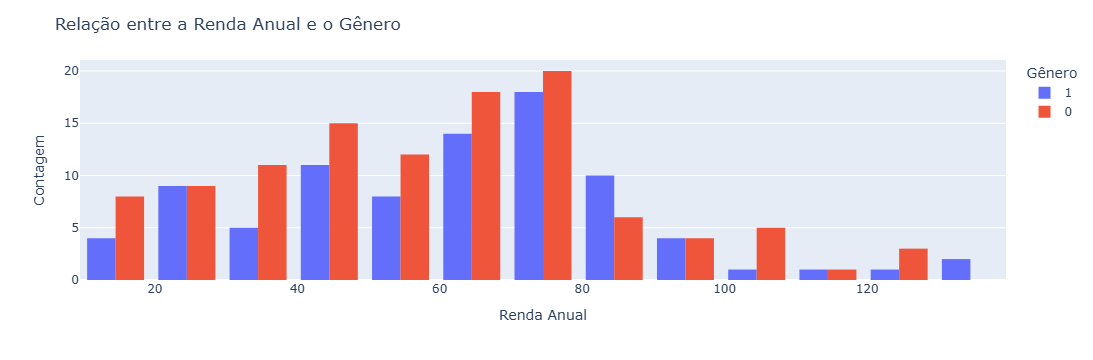

In [18]:
fig = px.histogram(df_encoded, x='Annual Income', color='Gender', barmode='group')

fig.update_layout(title='Relação entre a Renda Anual e o Gênero',
                  xaxis_title='Renda Anual',
                  yaxis_title='Contagem',
                  legend_title='Gênero')

fig.show()   

**Neste gráfico podemos que a maior parte dos clientes concentra-se em faixas intermediárias de renda, com menor presença em extremos.**

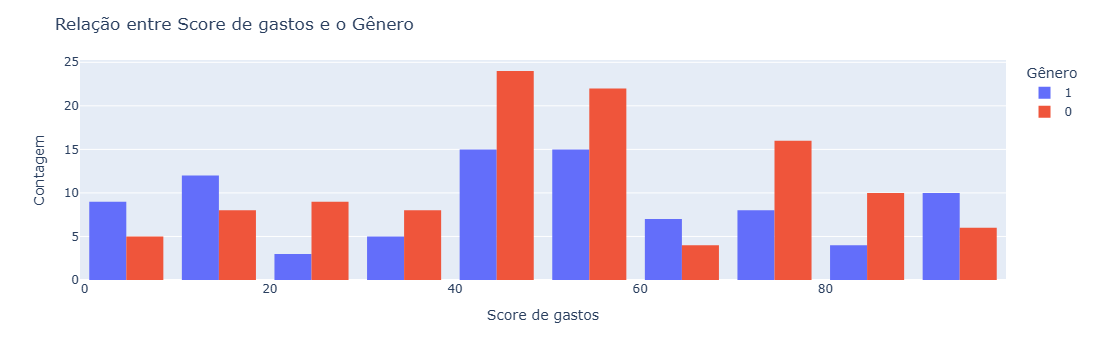

In [19]:
fig = px.histogram(df_encoded, x='Spending Score', color='Gender', barmode='group')

fig.update_layout(title='Relação entre Score de gastos e o Gênero',
                  xaxis_title='Score de gastos',
                  yaxis_title='Contagem',
                  legend_title='Gênero')

fig.show()   

**A distribuição do score de gastos é relativamente semelhante entre os gêneros, sem diferenças expressivas que indiquem comportamento de consumo significativamente distinto**

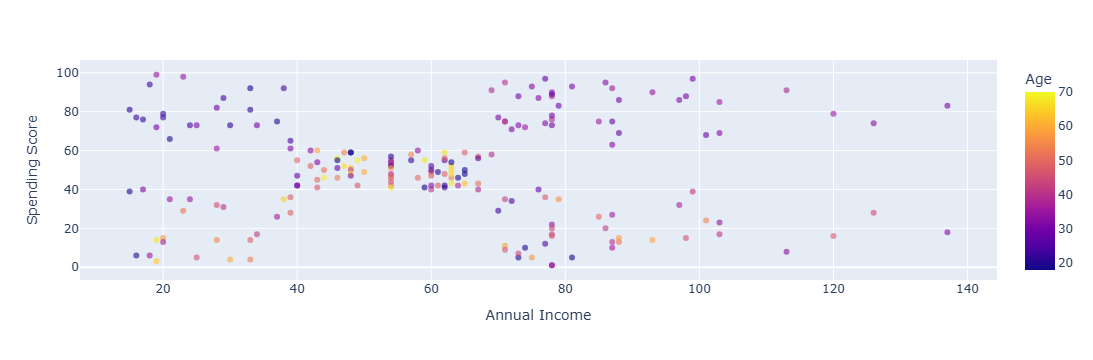

In [20]:
fig = px.scatter(df_encoded,x='Annual Income',y='Spending Score', color='Age',opacity=0.6)

fig.show()

**De acordo com o gráfico de disperssão podemos retirar que existem 3 perfis de consumo: Clientes com Alta Renda e alto gasto, Alta Renda e Baixo gasto e baixa renda e alto gasto**

# Agora vamos para a parte de Correlação, padronização de variáveis e utilização do k-means

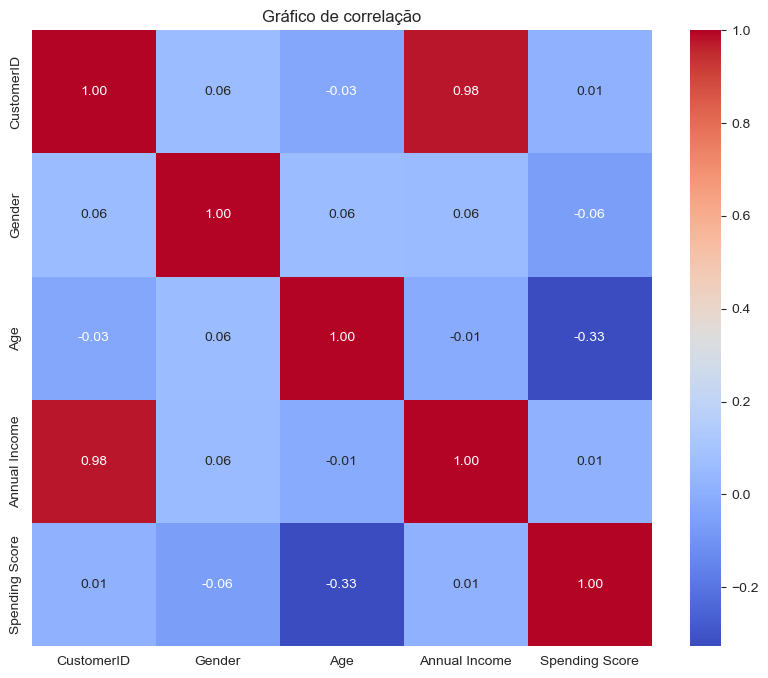

In [21]:
#Plotando a matriz de correlação
correlacao = df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlacao,annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Gráfico de correlação')
plt.show()

**Nesta matriz podemos notar uma correlação muito forte de Annual Income com o CustomerID uma correlação negativa entre Spending Score e Age**

In [52]:
# Padronizando os valores 
# Escolhi por criar arrays com as variáveis importantes pois se eu criasse um df geraria ruido que dificultaria a análise
colunas_padronizar_2 = ['Annual Income','Spending Score']

# Inicializando o StandardScaler
scaler = StandardScaler()

# Criar array padronizado (não precisa ser DataFrame ainda)
X_scaled_2 = scaler.fit_transform(df_encoded[colunas_padronizar_2])

In [24]:
X_scaled_2

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [23]:
colunas_padronizar_2 = ['Annual Income','Spending Score']

# Inicializando o StandardScaler
scaler = StandardScaler()

# Criar array padronizado (não precisa ser DataFrame ainda)
X_scaled_2 = scaler.fit_transform(df_encoded[colunas_padronizar_3])

In [26]:
#aplicando o k-means com 2 clusters
kmeans_shopping_2 = KMeans (n_clusters=2, n_init=10, random_state=42)
kmeans_shopping_2.fit(X_scaled_2)

C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [28]:
# Centroides
centroides_2 = kmeans_shopping_2.cluster_centers_
centroides_2

array([[ 0.08359105,  1.02764758],
       [-0.05123322, -0.62984851]])

In [29]:
#Verificando a forma dos meus centroides
centroides_2 = kmeans_shopping_2.cluster_centers_
print(centroides_2.shape)

(2, 2)


### Construindo a matriz de disperssão para Annual Income e Gender

In [30]:
# Revertendo padronização
centroides_padronizados_2 = kmeans_shopping_2.cluster_centers_

#Revertendo a padronização para encontrar os valores originais dos centroides
centroides_originais_2 = scaler.inverse_transform(centroides_padronizados_2)
centroides_originais_2

array([[62.75      , 76.67105263],
       [59.21774194, 33.97580645]])

**Neste Centroides podemos identificar 2 tipos de consumidores aqueles com uma renda alta e um alto consumo e outro com uma renda mais baixa mas um consumo mais baixo também indicando clientes mais conservadores**

In [31]:
# Criando as labels
labels_2 = kmeans_shopping_2.labels_
labels_2

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

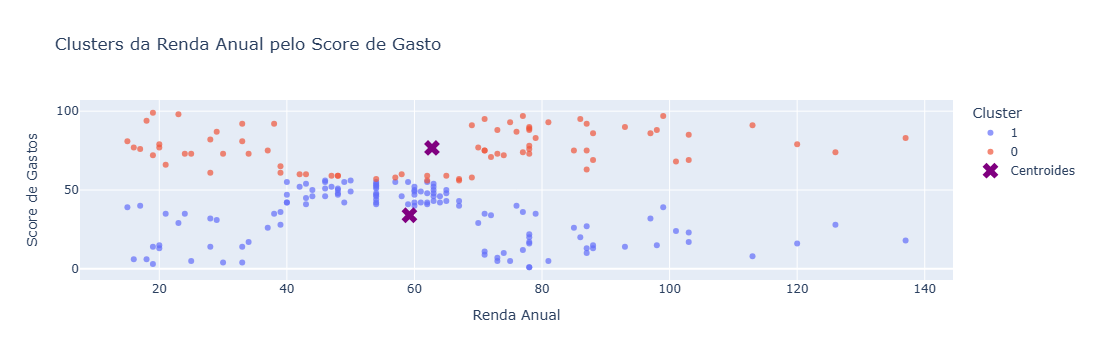

In [33]:
#Criando a matriz de disperssão
df_clusters_2 = pd.DataFrame({
    'Renda_Anual': df_encoded['Annual Income'],
    'Score_de_Gastos': df_encoded['Spending Score'],
    'cluster': labels_2.astype(str)
})


fig = px.scatter(df_clusters_2, x='Renda_Anual', y='Score_de_Gastos', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters da Renda Anual pelo Score de Gasto')

fig.add_scatter(x=centroides_originais_2[:, 0], y=centroides_originais_2[:, 1],
                mode='markers', marker=dict(color='purple', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Renda Anual', yaxis_title='Score de Gastos',
                  legend_title='Cluster')
fig.show()

**Observa-se que temos clientes com um poder aquisitivo maior que gastam bastante e cliente com uma idade um pouco maior que possuem um perfil mais conservador de gastos**

In [34]:
df['cluster'] = labels_2

In [35]:
media_por_cluster = df.groupby('cluster')[['Annual Income','Spending Score']].mean()
media_por_cluster.style.format("{:.2f}")

,Annual Income,Spending Score
cluster,,
0,62.75,76.67
1,59.22,33.98


### Conseguimos identificar 2 grupos distintos de consumidores:

**0 - Pessoas com alta renda e altos gastos, onde temos que manter a fidelização com ofertas exclusivas e lançamentos antecipados**

**1 - Pessoas com uma renda um pouco menor mas com padrões de gastos mais baixos indicando consumidores mais conservadores, precisamos atrair com cupons de desconto, campanhas publicitaárias e ofertas mais simples e diretas**

### Agora vamos testar o mesmo modelo com 3 clusters

In [36]:
#Agora vou criar outro modelo com 3 clusters para isso eu vou criar outro array recebendo 3 colunas padronizadas
colunas_padronizar_3 = ['Annual Income','Age','Spending Score']

X_scaled_3 = scaler.fit_transform(df_encoded[colunas_padronizar_3])

In [37]:
# Visualizando os dados
X_scaled_3

array([[-1.73899919, -1.42456879, -0.43480148],
       [-1.73899919, -1.28103541,  1.19570407],
       [-1.70082976, -1.3528021 , -1.71591298],
       [-1.70082976, -1.13750203,  1.04041783],
       [-1.66266033, -0.56336851, -0.39597992],
       [-1.66266033, -1.20926872,  1.00159627],
       [-1.62449091, -0.27630176, -1.71591298],
       [-1.62449091, -1.13750203,  1.70038436],
       [-1.58632148,  1.80493225, -1.83237767],
       [-1.58632148, -0.6351352 ,  0.84631002],
       [-1.58632148,  2.02023231, -1.4053405 ],
       [-1.58632148, -0.27630176,  1.89449216],
       [-1.54815205,  1.37433211, -1.36651894],
       [-1.54815205, -1.06573534,  1.04041783],
       [-1.54815205, -0.13276838, -1.44416206],
       [-1.54815205, -1.20926872,  1.11806095],
       [-1.50998262, -0.27630176, -0.59008772],
       [-1.50998262, -1.3528021 ,  0.61338066],
       [-1.43364376,  0.94373197, -0.82301709],
       [-1.43364376, -0.27630176,  1.8556706 ],
       [-1.39547433, -0.27630176, -0.590

In [40]:
kmeans_shopping_3 = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_shopping_3.fit(X_scaled_3)

C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [41]:
#Repetindo o mesmo processo dos centroides agora somente com 2 clusters
centroides_padronizados_3 = kmeans_shopping_3.cluster_centers_
centroides_originais_3 = scaler.inverse_transform(centroides_padronizados_3)
centroides_originais_3

array([[42.75      , 25.83823529, 53.64705882],
       [87.34146341, 32.85365854, 79.97560976],
       [61.8021978 , 51.27472527, 34.20879121]])

### Aqui encontramos 3 perfiz diferentes de consumidores

**0 - O consumidor com menor poder aquisitivo, jovem mas com um consumo elevado**

**1 - Um consumidor com maior poder aquisitivo, provavelmente um jovem adulto com um consumo elevado também**

**2 - Um consumidor com um podera aquisitivo médio, de uma idade mais avançada porém com um padrão de consumo mais conservador**

In [45]:
centroides_3 = kmeans_shopping_3.cluster_centers_
print(centroides_3.shape)

(3, 3)


In [44]:
# Revertendo padronização
centroides_padronizados_3 = kmeans_shopping_3.cluster_centers_

#Revertendo a padronização para encontrar os valores originais dos centroides
centroides_originais_3 = scaler.inverse_transform(centroides_padronizados_3)
centroides_originais_3

array([[42.75      , 25.83823529, 53.64705882],
       [87.34146341, 32.85365854, 79.97560976],
       [61.8021978 , 51.27472527, 34.20879121]])

In [42]:
labels_3 = kmeans_shopping_3.labels_
labels_3

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0,
       0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       1, 1], dtype=int32)

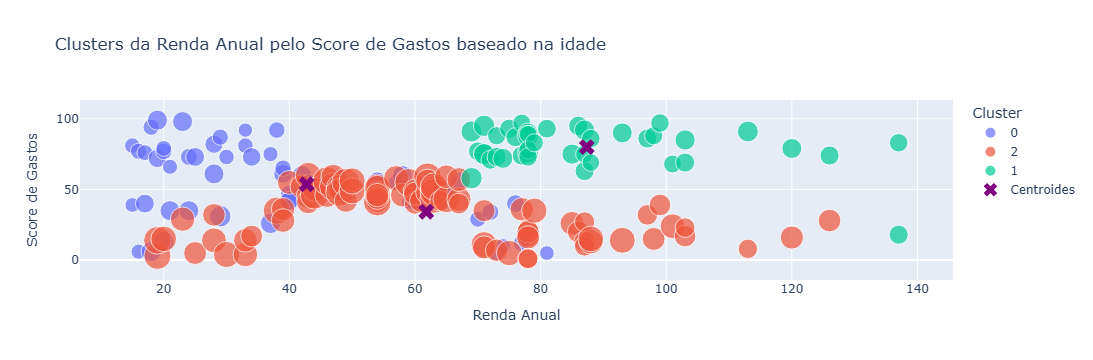

In [46]:
df_clusters_3= pd.DataFrame({
    'Renda_Anual': df_encoded['Annual Income'],
    'Score_de_Gastos': df_encoded['Spending Score'],
    'Idade': df_encoded['Age'],
    'cluster': labels_3.astype(str)
})

#Utilizei a idade como size para detalhar um padrão de consumo
fig = px.scatter(df_clusters_3, x='Renda_Anual', y='Score_de_Gastos', color='cluster', size='Idade',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters da Renda Anual pelo Score de Gastos baseado na idade')

fig.add_scatter(x=centroides_originais_3[:, 0], y=centroides_originais_3[:, 2],
                mode='markers', marker=dict(color='purple', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Renda Anual', yaxis_title='Score de Gastos',
                  legend_title='Cluster')
fig.show()

**Como detalhado anteriormente na explicação dos centroides no gráfico podemos visualizar os 3 padrões de consumo, o de renda mais baixa e um consumo alto, renda mais alta e consumo mais alto e um de idade mais avançada e um consumo moderado indicando um consumo mais conservador**

In [47]:
df['cluster'] = labels_3

In [50]:
media_por_cluster = df.groupby('cluster')[['Annual Income','Age','Spending Score']].mean()
media_por_cluster.style.format("{:.2f}")

,Annual Income,Age,Spending Score
cluster,,,
0,42.75,25.84,53.65
1,87.34,32.85,79.98
2,61.80,51.27,34.21


### Aqui identificamos 3 grupos:

**0 - Um publico com baixa renda mas alta frequencia de compra onde podemos criar campanhas em redes sociais, fornecer condições maiores de parcelamento, e mais produtos de entrada**

**1 - Publico com alta renda e alto score de gastos, podemos oferecer produtos premium com experiências e atendimentos diferenciados e também um programa de fidelidade**

**2 - Publico com médio poder aquisitivo, mais velhos com padrões de compra mais conservadores que podemos atrair com mais provas sociais como reviews do produto, uma comunicação mais clara e objetiva e menos urgência e mais confiança**